# Adaptive Noise Gate
An adaptive noise gate where the thresholds track recent frame energies, allowing the system to adjust dynamically to changing noise environments.

## Creating a test signal

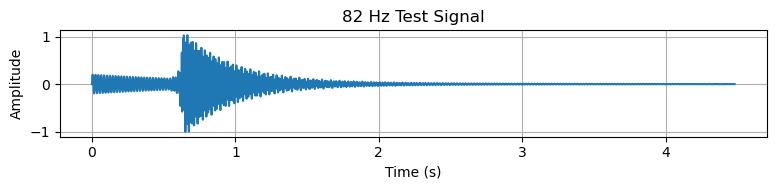

In [78]:
import numpy as np
from utils import (create_guitar_signal,  
                   create_sinewave, 
                   plot_gate_debug,
                   plot_signal,
                   load_floats_csv)
frame_len = 1024
freq = 82
fs = 8000
N1, N2 = 30,  5
hum_freq, hum_amp = 50, 0.2

s1, _ = create_guitar_signal(fs, freq, N1*frame_len, amplitude=1, decay_rate=3.0)
s2, _ = create_guitar_signal(fs, freq, N2*frame_len, amplitude=1, decay_rate=45.0)
s3, _ = create_sinewave(fs, hum_freq, (N1 + N2)*frame_len, hum_amp,1)

s2_rev = s2[::-1]
signal = np.concatenate([s2_rev, s1]) + s3
time = np.arange(len(signal)) / fs

plot_signal(signal=signal, time=time, title=f"{freq} Hz Test Signal", figsize=(8, 2))

## Adaptive Noise Gate
An adaptive noise gate that processes audio one frame at a time while maintaining a rolling history of the last 20 frames below the threshold. The noise floor is estimated from this history, and the open/close thresholds drift with recent frame energies, allowing the gate to adapt dynamically to varying background noise levels and environments.

In [79]:
import numpy as np
from collections import deque
CLOSED, OPEN = 0,1 

class FrameState:
    def __init__(self,
                 Nbuf=20,
                 floor_pct=15,
                 delta_on=9.0,
                 delta_off=2.0,
                 hang_frames=8,
                 include_open=False):
        self.Nbuf = Nbuf
        self.floor_pct = floor_pct
        self.delta_on = delta_on
        self.delta_off = delta_off
        self.hang_frames = hang_frames
        self.include_open = include_open
        self.buf = deque(maxlen=Nbuf)
        self.gate = CLOSED
        self.hang = 0
        self.init = False

def adaptive_noise_gate_step(frame, st: FrameState):

    energy = np.sum(frame**2)

    EPS = 1e-20
    E_db = 10.0 * np.log10(energy if energy > EPS else EPS)

    if not st.init:
        st.buf.clear(); st.buf.append(E_db)
        F = np.percentile(np.fromiter(st.buf, float), st.floor_pct)
        Ton, Toff = F + st.delta_on, F + st.delta_off
        st.gate = CLOSED
        st.hang = 0
        st.init = True
        return E_db, F, Ton, Toff, st.gate

    if (st.gate == CLOSED) or st.include_open:
        st.buf.append(E_db)

    buf_arr = np.fromiter(st.buf, float)
    F = np.percentile(buf_arr, st.floor_pct)
    Ton, Toff = F + st.delta_on, F + st.delta_off

    if st.gate == CLOSED:
        if E_db >= Ton:
            st.gate = OPEN
            st.hang = st.hang_frames
    else:
        if (E_db <= Toff) and (st.hang == 0):
            st.gate = CLOSED
        else:
            st.hang = max(st.hang - 1, 0)

    return E_db, F, Ton, Toff, st.gate

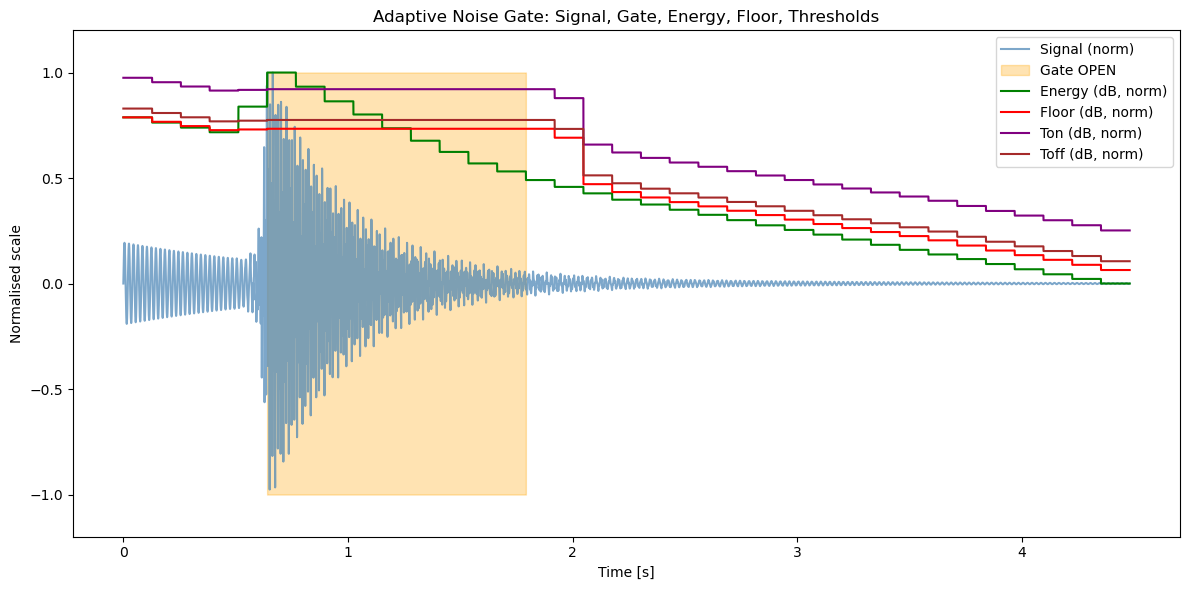

In [80]:
def run_adaptive_gate(signal, frame_len, fs, state_cls=FrameState):

    n_frames = len(signal) // frame_len
    signal = signal[: n_frames * frame_len]
    time = np.arange(len(signal)) / fs

    Ton_list, Toff_list, E_db_list, F_list, gate_list = [], [], [], [], []
    state = state_cls()

    for i in range(n_frames):
        frame = signal[i*frame_len : (i+1)*frame_len]
        E_db, F, Ton, Toff, gate = adaptive_noise_gate_step(frame, state)

        Ton_list.append(np.full(frame_len, Ton))
        Toff_list.append(np.full(frame_len, Toff))
        E_db_list.append(np.full(frame_len, E_db))
        F_list.append(np.full(frame_len, F))
        gate_list.append(np.full(frame_len, gate))

    Ton_arr  = np.concatenate(Ton_list)
    Toff_arr = np.concatenate(Toff_list)
    E_db_arr = np.concatenate(E_db_list)
    F_arr    = np.concatenate(F_list)
    gate_arr = np.concatenate(gate_list)

    return time, signal, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr


t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0)

plot_gate_debug(time, signal, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)

## Real Piezo Signal

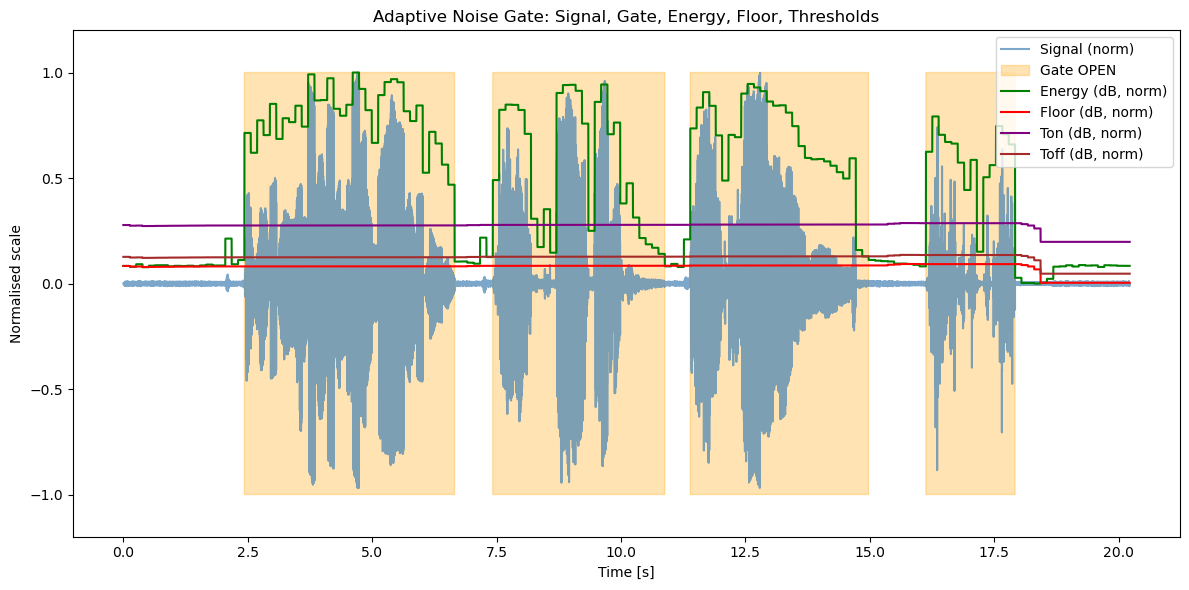

In [81]:
signal_E2 = load_floats_csv("data/E2_signal.csv")
signal_A2 = load_floats_csv("data/A2_signal.csv")
signal_B3 = load_floats_csv("data/B3_signal.csv")
signal_floor = load_floats_csv("data/noise_floor.csv")
signal_bumps = load_floats_csv("data/bumps_signal.csv")

signal = np.concatenate([signal_floor, signal_B3, signal_A2, signal_E2, signal_bumps, signal_floor])
t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0)

plot_gate_debug(t,x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)

